In [2]:
import numpy as np  # util para computación científica en Python
import pandas as pd # biblioteca que contienen la estructura de datos de uso principal
import matplotlib.pyplot as plt
import os

In [4]:
#Cargar Datos limpios
path_salida = os.path.join('..','data', 'processed', 'global_freelancers_processed.csv')
df = pd.read_csv(path_salida)


Mapa de calor de cantidad de freelancers segun pais

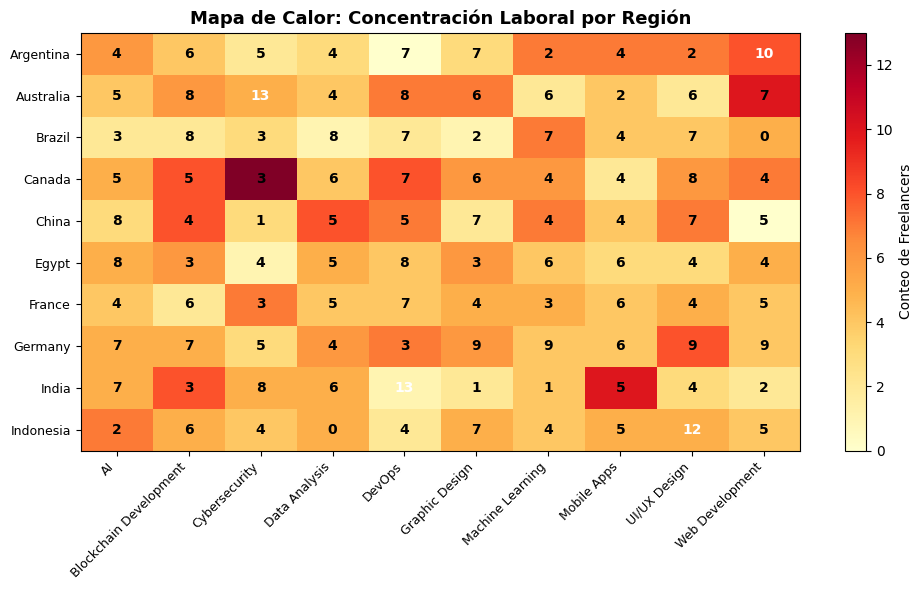

In [24]:
tabla_contingencia = pd.crosstab(df['country'], df['primary_skill']).head(10) # Acotado para legibilidad
paises_top = tabla_contingencia.index.tolist()
habilidades = tabla_contingencia.columns.tolist()

fig, ax = plt.subplots(figsize=(10, 6))
cax = ax.imshow(tabla_contingencia.values, cmap='YlOrRd', aspect='auto') # Cambiado de amarillo a rojo
fig.colorbar(cax, label='Conteo de Freelancers')

# Este codigo es para que se muestren los datos dentro de la matriz, de esa manera se entiende mejor
for i in range(len(paises_top)):
    for j in range(len(habilidades)):
        valor = matriz_datos[i, j]
        
        # Dinámica de contraste: si el fondo es rojo muy oscuro (valor alto), 
        # el texto se pinta blanco. Si es amarillo claro, se pinta negro.
        color_texto = "white" if valor > matriz_datos.max() * 0.75 else "black"
        
        # Dibujar el número en el centro de la celda (j = columna/X, i = fila/Y)
        ax.text(j, i, int(valor),
                ha="center", va="center", 
                color=color_texto, fontweight='bold', fontsize=10)


ax.set_xticks(np.arange(len(habilidades)))
ax.set_yticks(np.arange(len(paises_top)))
ax.set_xticklabels(habilidades, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(paises_top, fontsize=9)
ax.set_title('Mapa de Calor: Concentración Laboral por Región', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('mapa_calor_paises.png')
plt.show()

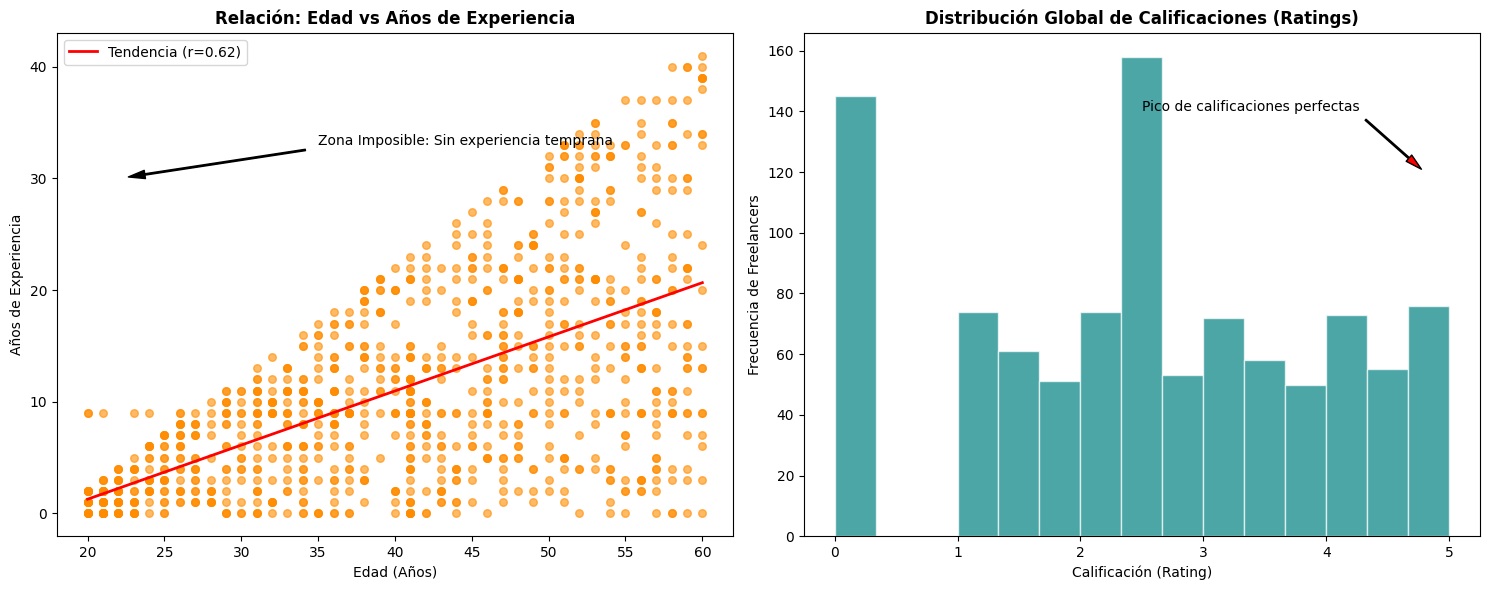

In [25]:
# Definir el tamaño del gráfico global (Punto 4 de diseño)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- SUBGRÁFICO 1: Gráfico de Dispersión (Tipo de gráfico 1) ---
ax1.scatter(df['age'], df['years_of_experience'], alpha=0.6, color='darkorange', s=30)
# Línea de tendencia con numpy
coef = np.polyfit(df['age'], df['years_of_experience'], 1)
polinomio = np.poly1d(coef)
ax1.plot(np.sort(df['age']), polinomio(np.sort(df['age'])), color='red', linewidth=2, label='Tendencia (r=0.62)')

ax1.set_title('Relación: Edad vs Años de Experiencia', fontsize=12, fontweight='bold') # Título y letras
ax1.set_xlabel('Edad (Años)', fontsize=10) # Etiquetas
ax1.set_ylabel('Años de Experiencia', fontsize=10)
ax1.legend() # Leyenda
ax1.annotate('Zona Imposible: Sin experiencia temprana', xy=(22, 30), xytext=(35, 33),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6)) # Anotación

# --- SUBGRÁFICO 2: Histograma (Tipo de gráfico 2) ---
ax2.hist(df['rating'], bins=15, color='teal', alpha=0.7, edgecolor='white')
ax2.set_title('Distribución Global de Calificaciones (Ratings)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Calificación (Rating)', fontsize=10)
ax2.set_ylabel('Frecuencia de Freelancers', fontsize=10)
ax2.annotate('Pico de calificaciones perfectas', xy=(4.8, 120), xytext=(2.5, 140),
             arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=6))

plt.tight_layout()
plt.savefig('panel_subgraficos.png', dpi=300) # Guardar en archivo
plt.show()